# Old Documents Cleanup & OCR Pipeline

A from-scratch build of a classic image-processing pipeline for cleaning up
scans of old/damaged documents and extracting the text via OCR.

**Pipeline stages:**
1. Load image
2. Grayscale conversion
3. Denoising (remove speckle/scan noise)
4. Deskew (straighten rotated scans)
5. Contrast enhancement (CLAHE)
6. Binarization (adaptive thresholding)
7. Morphological cleanup (remove small stains/specks)
8. OCR text extraction (Tesseract)

Each stage is visualized so you can see exactly what it's doing to the image.
Swap in your own scanned image in the **Load Image** cell to use this on real documents.


In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract

def show(img, title="", cmap=None):
    plt.figure(figsize=(7, 9))
    if cmap is None and (img.ndim == 2):
        cmap = "gray"
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_side_by_side(img1, img2, title1="Before", title2="After", cmap1=None, cmap2=None):
    if cmap1 is None and img1.ndim == 2:
        cmap1 = "gray"
    if cmap2 is None and img2.ndim == 2:
        cmap2 = "gray"
    fig, axes = plt.subplots(1, 2, figsize=(14, 9))
    axes[0].imshow(img1, cmap=cmap1)
    axes[0].set_title(title1)
    axes[0].axis("off")
    axes[1].imshow(img2, cmap=cmap2)
    axes[1].set_title(title2)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


## 1. Load Image

Replace the path below with your own scanned document (jpg/png/tiff all work).
A synthetic aged-document sample is included so this notebook runs end-to-end out of the box.

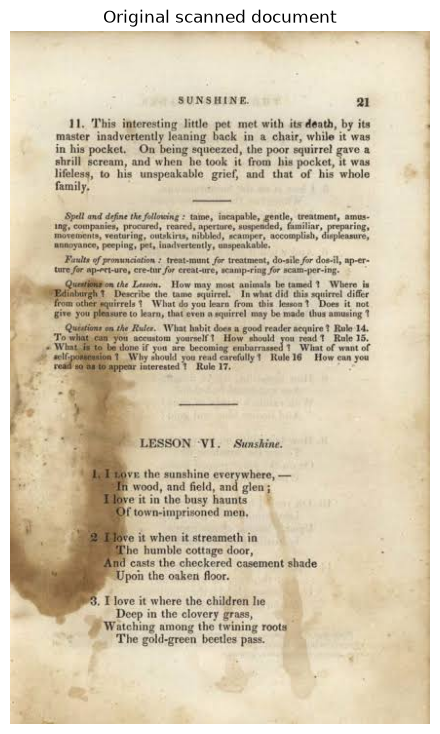

Image size: (711, 431, 3)


In [72]:
IMAGE_PATH = "../sample_data/images.jpeg"  # <-- point this at your own scan

original_bgr = cv2.imread(IMAGE_PATH)
original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

show(original_rgb, "Original scanned document")
print("Image size:", original_rgb.shape)


## 2. Grayscale Conversion

Color information isn't needed for text cleanup, and dropping it makes every
later step (denoising, thresholding, OCR) simpler and faster.

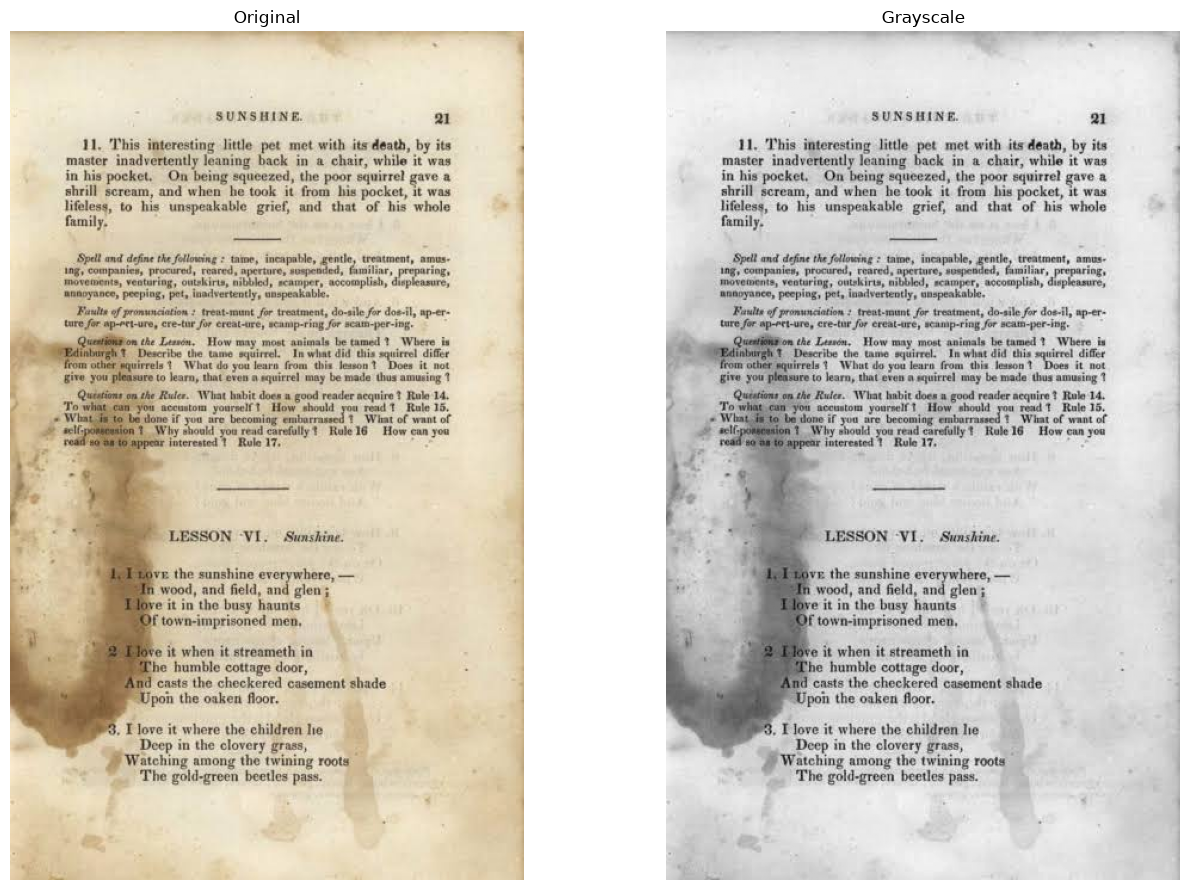

In [73]:
gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)
show_side_by_side(original_rgb, gray, "Original", "Grayscale")


## 3. Denoising

Old scans pick up speckle noise from paper grain, dust, and the scanning
process itself. `fastNlMeansDenoising` (Non-Local Means) smooths this out
while preserving text edges much better than a simple blur.

(We denoise and deskew *before* upscaling, further down — both of those steps
involve searching over many candidate pixels/angles, so running them at the
original, smaller resolution keeps this notebook fast. Upscaling only matters
for the fine-detail steps later: contrast enhancement, binarization, and OCR.)

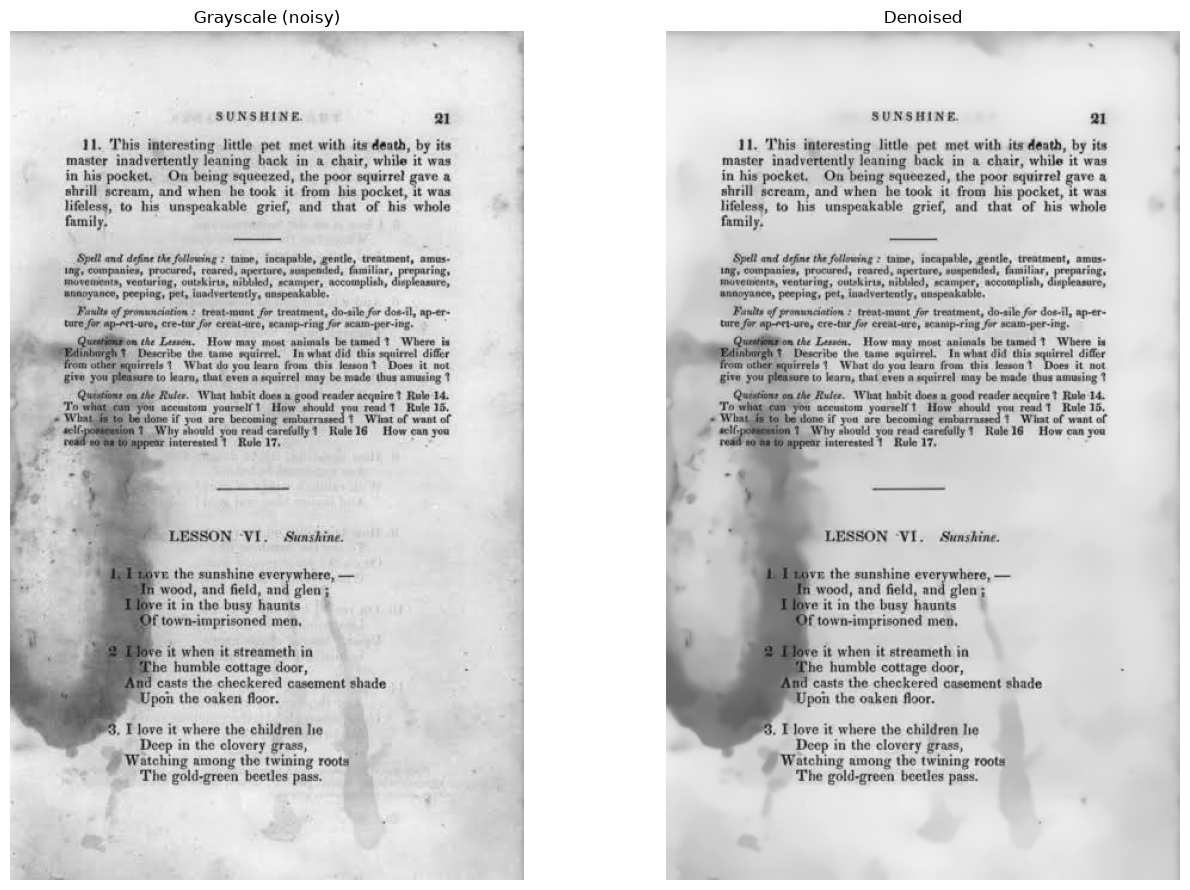

In [74]:
denoised = cv2.fastNlMeansDenoising(gray, h=8, templateWindowSize=7, searchWindowSize=21)
show_side_by_side(gray, denoised, "Grayscale (noisy)", "Denoised")


## 4. Deskew

Documents are rarely fed into a scanner perfectly straight. We use the
**projection profile method**: rotate a binarized copy of the image through
a range of small angles and measure how "peaky" the horizontal projection
(row-wise sum of ink pixels) is at each angle. Text lines produce sharp
peaks/valleys only when they're perfectly horizontal, so the angle with the
highest variance is the true skew angle. This is more robust than fitting a
single bounding rectangle, which gets thrown off by stains and irregular
paragraph shapes.

Detected skew angle: -0.10 degrees


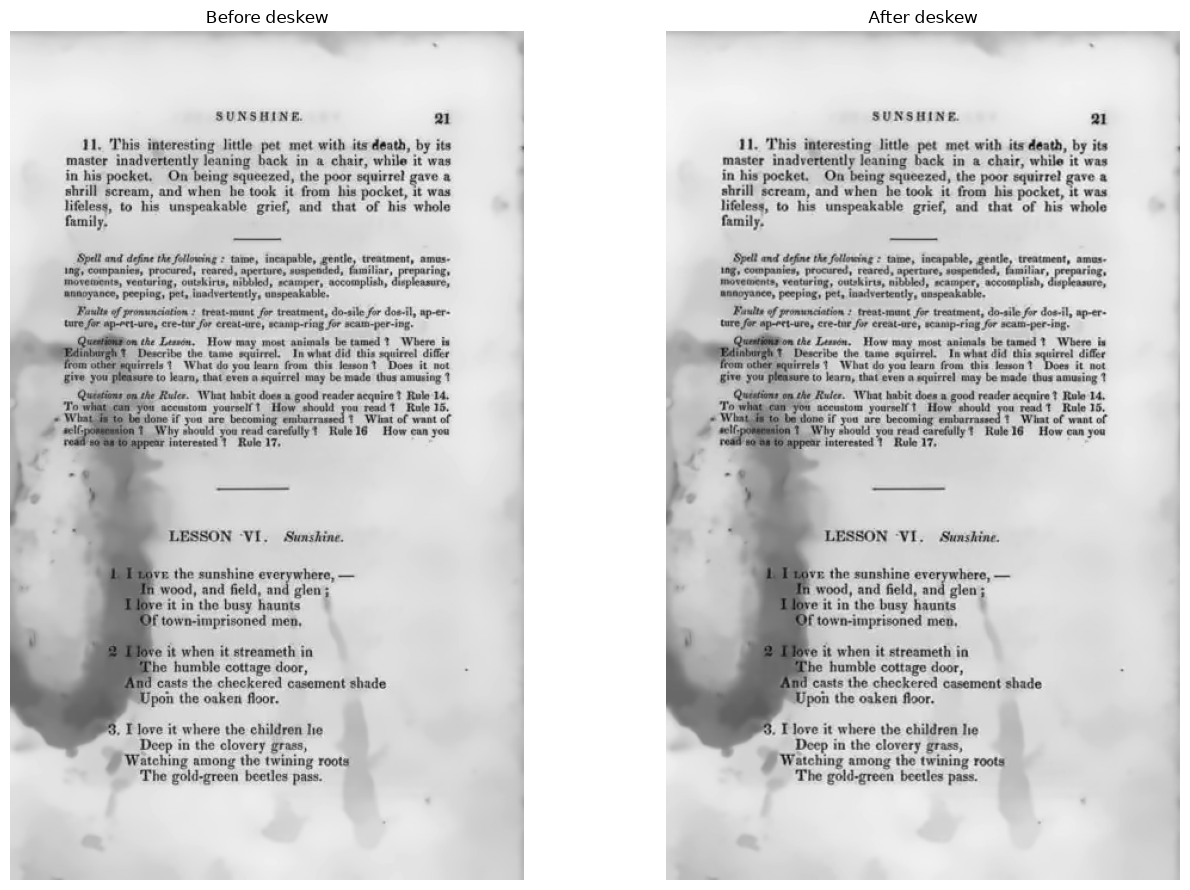

In [75]:
def get_skew_angle(image, angle_range=5.0, step=0.1):
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    (h, w) = thresh.shape
    center = (w // 2, h // 2)

    best_angle, best_score = 0.0, -1.0
    for angle in np.arange(-angle_range, angle_range + step, step):
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(thresh, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
        row_sums = rotated.sum(axis=1).astype(np.float64)
        score = row_sums.var()
        if score > best_score:
            best_score = score
            best_angle = angle
    return best_angle

def deskew(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

angle = get_skew_angle(denoised)
deskewed = deskew(denoised, angle)

print(f"Detected skew angle: {angle:.2f} degrees")
show_side_by_side(denoised, deskewed, "Before deskew", "After deskew")


## 4b. Upscale

Real photographed/scanned pages are often low-resolution relative to their
font size — individual letter strokes can end up only 1-2 pixels wide,
leaving almost no margin for the contrast/thresholding/OCR steps below to
work with. Upscaling now (after the more expensive denoise/deskew steps, to
keep this notebook fast) gives everything downstream more pixels to work
with — this tends to be the single biggest lever for OCR accuracy on small
or low-DPI scans.

If your source image is already high resolution (e.g. a proper flatbed scan
at 300+ DPI), set `UPSCALE_FACTOR = 1.0` to skip this.

In [76]:
UPSCALE_FACTOR = 3.0  # set to 1.0 to skip upscaling for already-high-DPI scans

if UPSCALE_FACTOR != 1.0:
    upscaled = cv2.resize(deskewed, None, fx=UPSCALE_FACTOR, fy=UPSCALE_FACTOR, interpolation=cv2.INTER_CUBIC)
else:
    upscaled = deskewed

print("Working image size:", upscaled.shape)


Working image size: (2133, 1293)


## 5. Contrast Enhancement (CLAHE)

Aged paper often has faded, uneven contrast (darker in some areas, washed out
in others). CLAHE (Contrast Limited Adaptive Histogram Equalization) boosts
local contrast without blowing out already-bright regions.

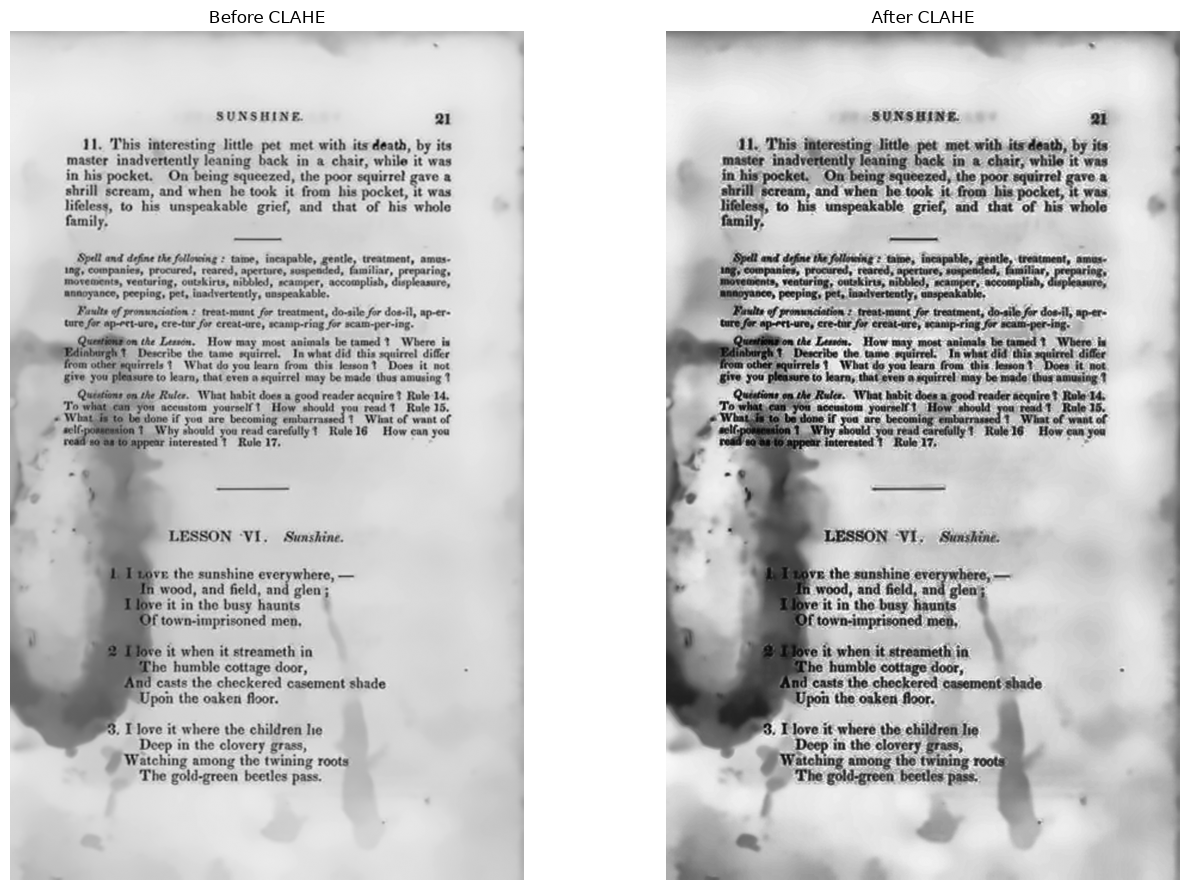

In [77]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
contrast_enhanced = clahe.apply(upscaled)
show_side_by_side(upscaled, contrast_enhanced, "Before CLAHE", "After CLAHE")


## 6. Binarization (Adaptive Thresholding)

Converting to pure black-and-white text-on-background is the single biggest
lever for OCR accuracy. Adaptive thresholding handles uneven lighting/aging
much better than a single global threshold.

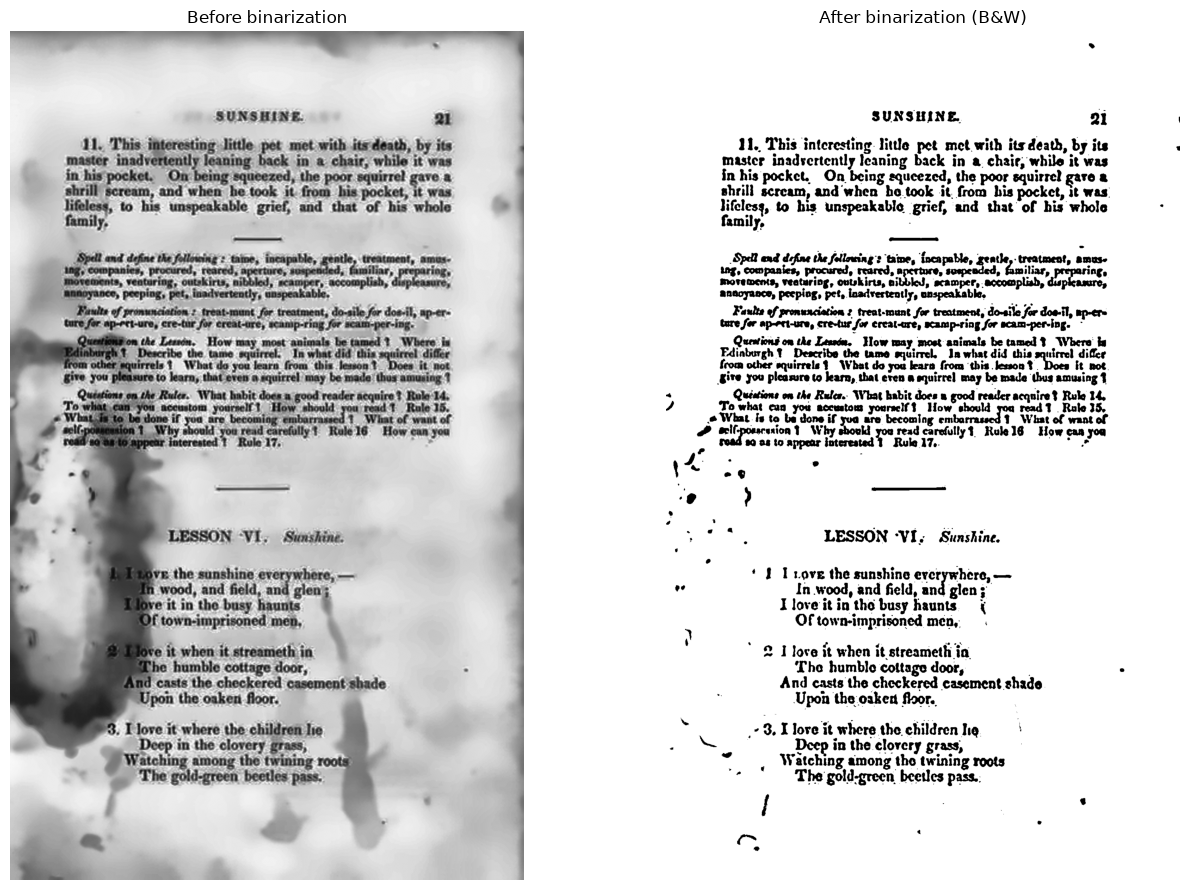

In [78]:
binarized = cv2.adaptiveThreshold(
    contrast_enhanced, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=51,
    C=20
)
show_side_by_side(contrast_enhanced, binarized, "Before binarization", "After binarization (B&W)")


## 7. Morphological Cleanup (optional — test before trusting it)

Small leftover specks (stains, dust, noise) can *sometimes* be cleaned up by
removing tiny isolated blobs. But this is risky: on small or serif fonts,
letter details (dots on `i`s, serifs, thin stems) can be just as small as
noise specks, so this step can end up deleting real text instead of cleaning
it up.

**Don't assume this step helps — verify it with your own image.** The cell
below runs OCR on the binarized image both with and without this step so you
can compare and decide for yourself.

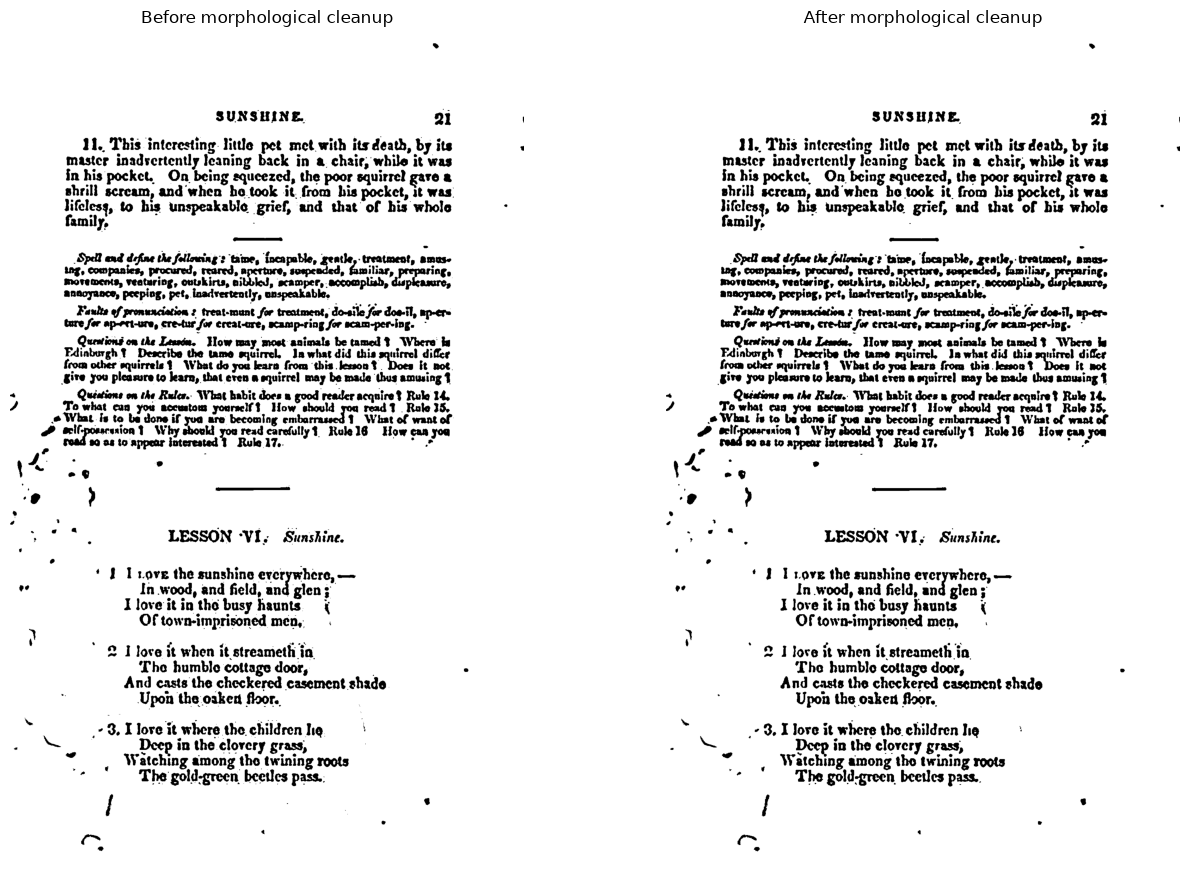

OCR WITHOUT morphological cleanup:
--------------------------------------------------
SUNSHINE. a1 ,
11. This interesting litle pet met.with its death, by its ‘
master inadvertently leaning back in a, chair, while it was
in his pocket. On being squeezed, the poor squirrel gare a
shrill scream, and when he took it. from his pocket, it was.
lifelesq, to his unspeakable grief, and that of his whole .
end define the folineing'? ‘aime, focapable, xeatle,. t,o
wi eagles Som aan Ae ene te

OCR WITH morphological cleanup:
--------------------------------------------------
SUNSHINE. Qi |
11. This interesting little pet met with its death, by its ‘
master inadvertently leaning back in a chair, while it was
in his pocket. On being squeezed, the poor squirrel? gare &
shrill scream, and when hbo took it, from bis pocket, it was
Jifelesq, to his unspeakable grief, and that of his whole .
aad the following’? tawe, {nca Mle, gentle treatment, a
tg, oan i dsr ec e r nt Boni


In [79]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
opened = cv2.morphologyEx(binarized, cv2.MORPH_OPEN, kernel)

# Remove small connected-component blobs (leftover stain fragments)
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(255 - opened, connectivity=8)
min_area = 6
mask = np.ones_like(opened) * 255
for i in range(1, n_labels):
    if stats[i, cv2.CC_STAT_AREA] < min_area:
        mask[labels == i] = 255
    else:
        mask[labels == i] = 0
morph_cleaned = mask

show_side_by_side(binarized, morph_cleaned, "Before morphological cleanup", "After morphological cleanup")

custom_config = r"--oem 3 --psm 6"
print("OCR WITHOUT morphological cleanup:")
print("-" * 50)
print(pytesseract.image_to_string(binarized, config=custom_config)[:400])
print()
print("OCR WITH morphological cleanup:")
print("-" * 50)
print(pytesseract.image_to_string(morph_cleaned, config=custom_config)[:400])


### Choose which version to carry forward

Based on the comparison above, pick whichever version actually scored better
for *your* image. Default here is to skip morphological cleanup, since it
tends to hurt more often than it helps unless you have large, well-separated
noise blobs and a large/bold font.

In [80]:
USE_MORPHOLOGICAL_CLEANUP = False  # flip to True only if step 7's comparison showed it helping

final_clean = morph_cleaned if USE_MORPHOLOGICAL_CLEANUP else binarized


## Full Pipeline, Side by Side

Original scan vs. fully cleaned output.

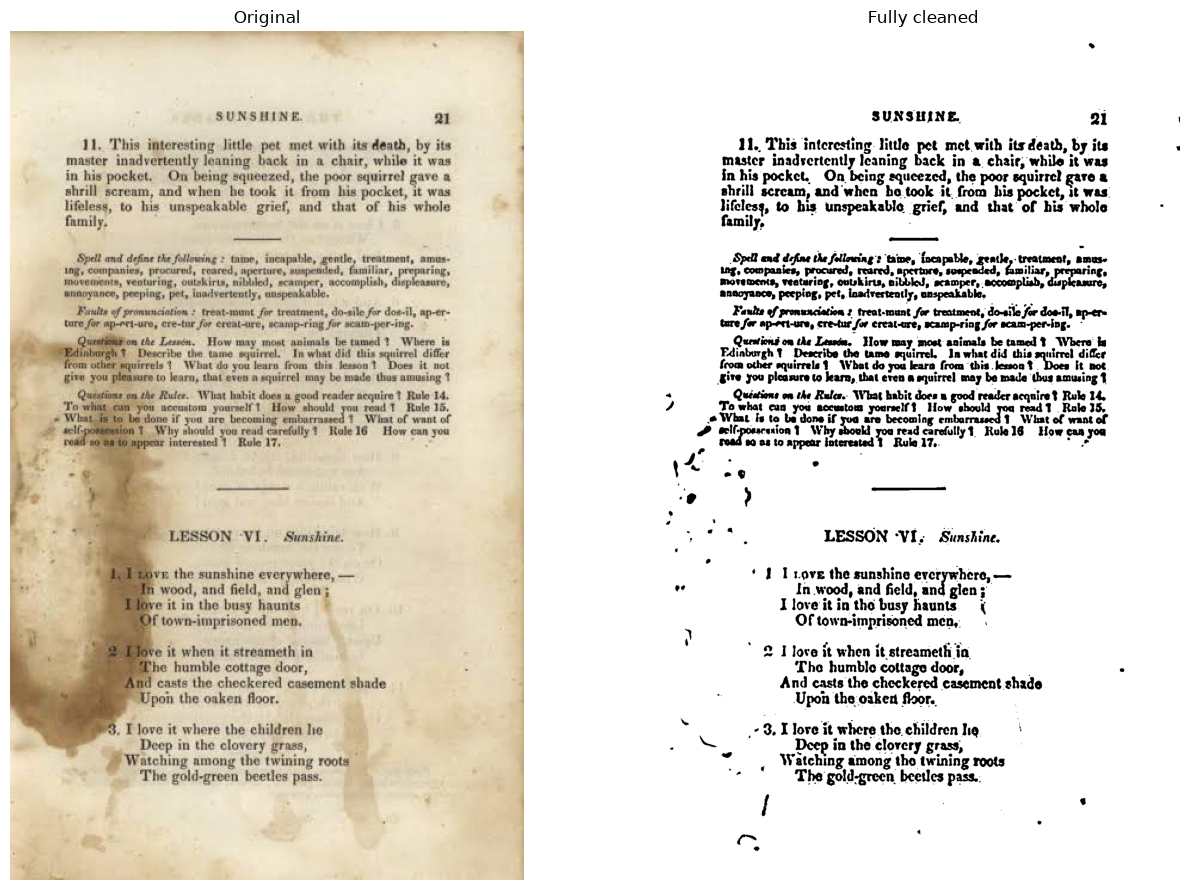

In [81]:
show_side_by_side(original_rgb, final_clean, "Original", "Fully cleaned", cmap2="gray")


## 8. OCR Text Extraction

With a clean, deskewed, high-contrast binary image, Tesseract has a much
easier time extracting accurate text.

In [82]:
custom_config = r"--oem 3 --psm 6"
extracted_text = pytesseract.image_to_string(final_clean, config=custom_config)

print("EXTRACTED TEXT:")
print("-" * 50)
print(extracted_text)


EXTRACTED TEXT:
--------------------------------------------------
SUNSHINE. a1 ,
11. This interesting litle pet met.with its death, by its ‘
master inadvertently leaning back in a, chair, while it was
in his pocket. On being squeezed, the poor squirrel gare a
shrill scream, and when he took it. from his pocket, it was.
lifelesq, to his unspeakable grief, and that of his whole .
end define the folineing'? ‘aime, focapable, xeatle,. t,o
wi eagles Som aan Ae ene te
Movements, veaturing, outskirts, nibbled, scamper, accomplish, upkeasure,
anaoyance, peeping, pet, inadvertently, onspeakable, — ;
Faulte of pronunciation 2 treat-munt for treatment, do-sile for doe-il, ap-er=
tore fer ap-ert-ure, cre-tur for creat-ore, scamp-ring for ecam-per-ing.
Questions on the Lessin. How may most animals be tamed ¥ Where’ is
Edinburgh Describe the tame squirrel. Ja what did this squirrel differ
{com other squirrels 1 What do you fears from ‘this lesson f Does ie not,
Gite you pleasure to learn, that even

### Bonus: compare OCR accuracy before vs. after cleanup

This shows *why* the pipeline matters - running OCR directly on the raw
scan versus the cleaned version.

In [83]:
raw_gray_text = pytesseract.image_to_string(gray, config=custom_config)
cleaned_text = pytesseract.image_to_string(final_clean, config=custom_config)

print("OCR on RAW grayscale scan:")
print("-" * 50)
print(raw_gray_text)
print()
print("OCR on CLEANED image:")
print("-" * 50)
print(cleaned_text)


OCR on RAW grayscale scan:
--------------------------------------------------
. '
SUNSHINE. a
11, ‘This intoresting little pet met with its deat, by its
master inadvertently Jeaning Back in a chit, wil it was
i his pocket. On being squeezed, irrel gave a
still foream, and when be touk Xt ffoa is pocket, t was |
lifeless, to his unspeakable grief, and that of his whole
family.
Spill an defe te llowing : ane, ingle, geal, treatment, ames
companies, procured, reared, Sropiaied, aie, ngs
‘nvtemem, restoring, omskira, ibe, semper, accomplish, depeamere,
omoyce peeping, ps inaverey, smepeskale
asl of yomenition : tretsunt for tetmant, do-sile fo dow mper=
weer apres sop for Deegerng.
* Dein the tase sei Ine de te mie et
‘a Wind eka Gt nan "Dwr it et
ie you plats to lar, tat een anil maybe made th omuniog?
; Reale. What habit dace good reader soiree 1.
eee ‘ccvitm yu) Hosa yu ad le 38,
#3 ry shoul yor ead erly Hale 16" How conor
e Tiered isl 7 =
'e
 - LESSON VI. Sunshine.
ee the sunshine ever

## 9. Save Outputs

Save the cleaned image and extracted text to disk.

In [84]:
import os
os.makedirs("output", exist_ok=True)

cv2.imwrite("output/cleaned_document.png", final_clean)

with open("output/extracted_text.txt", "w") as f:
    f.write(extracted_text)

print("Saved: output/cleaned_document.png")
print("Saved: output/extracted_text.txt")


Saved: output/cleaned_document.png
Saved: output/extracted_text.txt
